# PISA stage modes

Every PISA [stage](https://github.com/icecube/pisa/blob/master/pisa/core/stage.py) of a [pipeline](https://github.com/icecube/pisa/blob/master/pisa/core/pipeline.py) has a `calc_mode` and an `apply_mode`. Both instance attributes specify the "representation" in which generic [data](https://github.com/icecube/pisa/blob/master/pisa/core/container.py) (e.g., neutrino MC events) is processed through the pipeline. Often calculations can be faster when performed on grids, but we need to be careful in order to ensure that we are not introducing large errors.

More specifically, `calc_mode` by default defines the representation during the `setup()`and `compute()` steps, and `apply_mode` that during the `apply` step, see the [stages readme](https://github.com/icecube/pisa/blob/master/pisa/stages/README.md). The latter two steps are executed successively whenever a given stage instance is `run()`, during the pipeline output calculation. Like this, complex event-by-event calculations (e.g., oscillation probabilities) can for example be executed during the `compute()` step, which also has a basic caching mechanism to avoid redundant calculations. The `apply()` step typically performs simple transformations (using results of a preceding `compute()` step or not) of the data in the representation determined by `apply_mode`. Take a look at different stage implementations ("services") and example pipeline configuration files to get a better feel for the concept.

Note that you can change the modes on runtime, but after doing so need to `setup()` the stage or pipeline again (exercise: can you find a service which only defines its `setup()` step, but neither `compute()` nor `apply()`?).

If the output representation of a stage is different than what, for example, the next stage needs to have as input, the output is automatically translated by PISA (translation between data representations). So you can mix and match, but be aware that translations will introduce computational cost and hence may slow things down.

## Service implementation reference
This [auto-generated](https://github.com/icecube/pisa/blob/master/pisa_tests/test_services.py) table documents which methods each service implements, which representations it supports, as well as any deviant behavior or properties to be aware of.
It currently only contains services that can be **instantiated without importing optional PISA dependencies**.

**Legend:**
- **has_setup/compute/apply**: whether the service overrides setup/compute/apply_function (✓ = yes, ✗ = no)
- **calc_mode support**: allowed representations during setup/compute steps
- **apply_mode support**: allowed representations during apply step
- **Notes**: special behaviors, restrictions, problems, etc.

| Service | has_setup | has_compute | has_apply | calc_mode support | apply_mode support | Notes |
|---------|:---------:|:-----------:|:---------:|:-----------------:|:------------------:|-------|
| **absorption.earth_absorption** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **aeff.aeff** | ✗ | ✗ | ✓ | None | "events", "log_events", MultiDimBinning |  |
| **aeff.param** | ✗ | ✗ | ✓ | None | "events", "log_events", MultiDimBinning |  |
| **aeff.weight** | ✗ | ✗ | ✓ | None | "events", "log_events", MultiDimBinning |  |
| **aeff.weight_hnl** | ✗ | ✗ | ✓ | None | "events", "log_events", MultiDimBinning |  |
| **background.atm_muons** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **cont_sys.snowstorm_hist** | ✓ | ✓ | ✓ | "events" | None, MultiDimBinning |  |
| **data.csv_data_hist** | ✓ | ✗ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))**, setup only |
| **data.csv_icc_hist** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **data.csv_loader** | ✓ | ✗ | ✓ | "events" | "events" |  |
| **data.grid** | ✓ | ✗ | ✓ | "events" | "events", "log_events", MultiDimBinning |  |
| **data.meows_loader** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **data.simple_data_loader** | ✓ | ✗ | ✓ | None | "events" |  |
| **data.sqlite_loader** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **data.toy_event_generator** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **discr_sys.csv_hypersurfaces** | ✓ | ✓ | ✓ | MultiDimBinning | MultiDimBinning, "events" |  |
| **discr_sys.hypersurfaces** | ✓ | ✓ | ✓ | MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **discr_sys.ultrasurfaces** | ✓ | ✓ | ✓ | "events" | "events", "log_events", MultiDimBinning |  |
| **flux.astrophysical** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **flux.barr_simple** | ✓ | ✓ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))** |
| **flux.daemon_flux** | ✓ | ✓ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))** |
| **flux.hillasg** | ✓ | ✓ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))** |
| **flux.honda_ip** | ✓ | ✓ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))** |
| **flux.mceq_barr** | ✓ | ✓ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))** |
| **flux.mceq_barr_red** | ✓ | ✓ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))** |
| **likelihood.generalized_llh_params** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | MultiDimBinning |  |
| **osc.decoherence** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **osc.globes** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **osc.prob3** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **osc.two_nu_osc** | ✗ | ✗ | ✓ | None | "events", "log_events", MultiDimBinning |  |
| **reco.resolutions** | ✓ | ✗ | ✗ | "events" | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))**, setup only |
| **reco.simple_param** | ✓ | ✗ | ✗ | "events", "log_events", MultiDimBinning | None | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))**, setup only |
| **utils.add_indices** | ✓ | ✗ | ✗ | "events" | MultiDimBinning | ⚠️ **Implicit caching ([#821](https://github.com/icecube/pisa/issues/821))**, setup only |
| **utils.adhoc_sys** | ✓ | ✗ | ✓ | "events" | "events" |  |
| **utils.bootstrap** | ✓ | ✗ | ✓ | "events" | "events", "log_events", MultiDimBinning |  |
| **utils.fix_error** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **utils.hist** | ✓ | ✗ | ✓ | MultiDimBinning, "events" | None, MultiDimBinning |  |
| **utils.kde** | ✓ | ✗ | ✓ | "events" | MultiDimBinning |  |
| **utils.kfold** | ✓ | ✗ | ✓ | "events" | "events", "log_events", MultiDimBinning |  |
| **utils.set_variance** | ✓ | ✓ | ✓ | MultiDimBinning | MultiDimBinning |  |
| **xsec.correct_charm_y** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **xsec.dis_sys** | ✓ | ✗ | ✓ | "events" | "events", "log_events", MultiDimBinning |  |
| **xsec.genie_sys** | ✓ | ✗ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |
| **xsec.nutau_xsec** | ✓ | ✓ | ✓ | "events", "log_events", MultiDimBinning | "events", "log_events", MultiDimBinning |  |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pisa.core.pipeline import Pipeline

We will configure our neutrino pipeline in 3 different ways:
* The standard form with *some* calculation on grids
* All calculations on an event-by-event basis (the most correct, but by far slowest way)
* All calculations on grids (usually faster for large event samples)

In [2]:
mixed_modes_model = Pipeline("settings/pipeline/IceCube_3y_neutrinos.cfg", profile=True)

In [3]:
events_modes_model = Pipeline("settings/pipeline/IceCube_3y_neutrinos.cfg", profile=True)

events_modes_model.stages[1].calc_mode = "events"
events_modes_model.stages[2].calc_mode = "events"
events_modes_model.stages[3].calc_mode = "events"

events_modes_model.setup()

In [4]:
grid_modes_model = Pipeline("settings/pipeline/IceCube_3y_neutrinos.cfg", profile=True)

true_binning = grid_modes_model.stages[1].calc_mode

for s in grid_modes_model.stages[:-2]:
    try:
        s.calc_mode = true_binning
    except:
        pass
    try:
        s.apply_mode = true_binning
    except:
        pass
grid_modes_model.stages[5].calc_mode = true_binning
grid_modes_model.setup()

In [5]:
mixed_modes_model

stage number,name,calc_mode,apply_mode,has setup,has compute,has apply,# fixed params,# free params
0,csv_loader,events,events,True,False,True,0,0
1,honda_ip,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",,True,True,False,1,0
2,barr_simple,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",,True,True,False,1,4
3,prob3,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",events,True,True,True,9,3
4,aeff,,events,False,False,True,2,3
5,hist,events,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,False,True,0,0
6,hypersurfaces,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,True,True,0,5


In [6]:
events_modes_model

stage number,name,calc_mode,apply_mode,has setup,has compute,has apply,# fixed params,# free params
0,csv_loader,events,events,True,False,True,0,0
1,honda_ip,events,,True,True,False,1,0
2,barr_simple,events,,True,True,False,1,4
3,prob3,events,events,True,True,True,9,3
4,aeff,,events,False,False,True,2,3
5,hist,events,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,False,True,0,0
6,hypersurfaces,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,True,True,0,5


In [7]:
grid_modes_model

stage number,name,calc_mode,apply_mode,has setup,has compute,has apply,# fixed params,# free params
0,csv_loader,events,events,True,False,True,0,0
1,honda_ip,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",,True,True,False,1,0
2,barr_simple,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",,True,True,False,1,4
3,prob3,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)","""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",True,True,True,9,3
4,aeff,,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",False,False,True,2,3
5,hist,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)","""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,False,True,0,0
6,hypersurfaces,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,True,True,0,5


We can compare timings. Event-by-event it takes around 8 minutes! The two other modes around 25 seconds.

**Note**: To speed up the following `get_outputs()` calls, consider running this notebook after having set the environment variables `PISA_TARGET="parallel"` and `PISA_NUM_THREADS = <some number of threads > 1>`.

In [10]:
%%time
events = events_modes_model.get_outputs()

CPU times: user 6min 42s, sys: 36.8 ms, total: 6min 42s
Wall time: 6min 42s


In [8]:
%%time
mixed = mixed_modes_model.get_outputs()

CPU times: user 25.2 s, sys: 15.8 ms, total: 25.2 s
Wall time: 25.4 s


In [9]:
%%time
grid = grid_modes_model.get_outputs()

CPU times: user 21.8 s, sys: 8.19 ms, total: 21.8 s
Wall time: 21.5 s


We can see that in this configuration we probably have fine enough grids, such that differences are at the sub-percent level. This may or may not be acceptable for the specific analysis you want to do.

(<Figure size 2000x700 with 18 Axes>,
 <Axes: title={'center': '${\\nu_{\\rm all}} + {\\bar\\nu_{\\rm all}},{\\;}{\\rm PID}{\\;}bin{\\;}0$'}, xlabel='$E_{\\rm reco} \\; \\left( \\mathrm{GeV} \\right)$', ylabel='$\\cos{\\theta}_{\\rm reco}$'>,
 None)

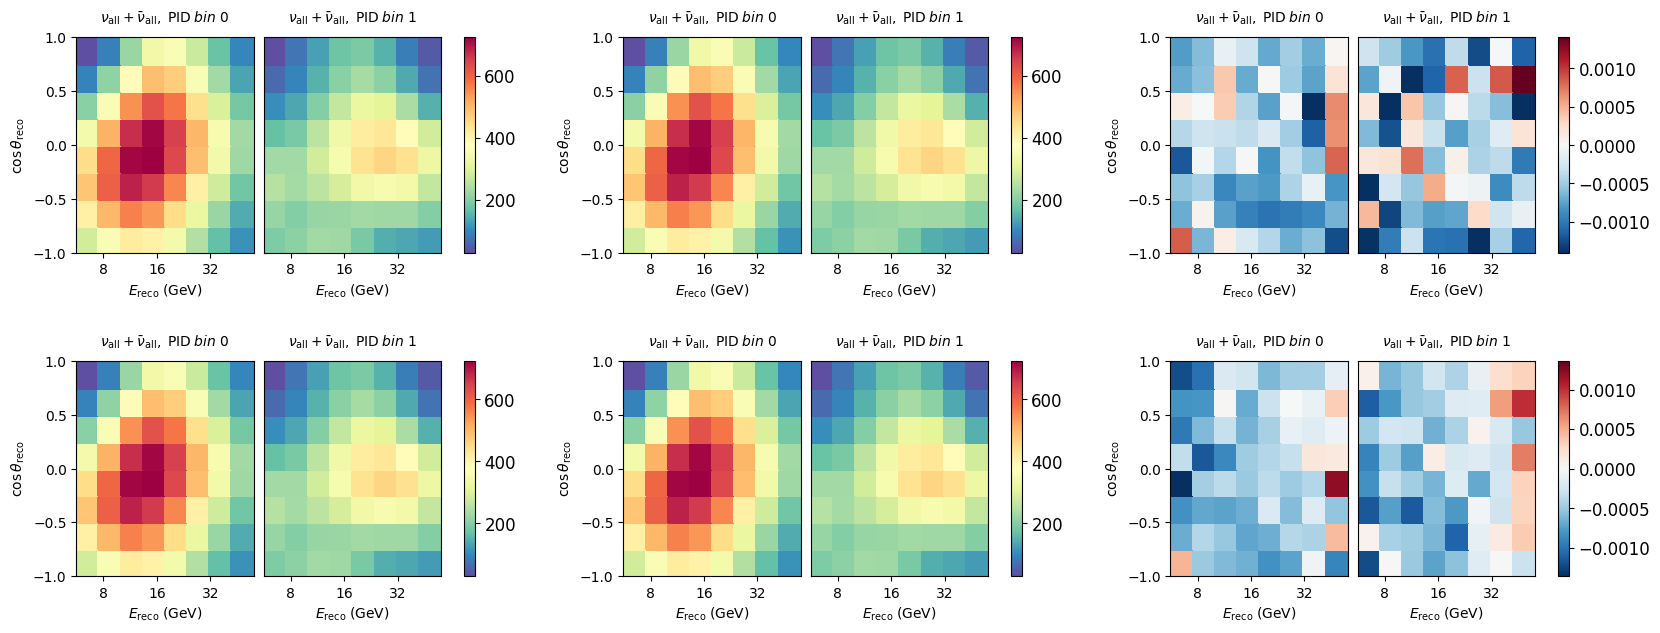

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(20, 7))
plt.subplots_adjust(hspace=0.5)

e = events.combine_wildcard('*')
m = mixed.combine_wildcard('*') 
g = grid.combine_wildcard('*') 

e.plot(ax=ax[0,0], title="Events")
m.plot(ax=ax[0,1], title="Mixed")
((e - m)/e).plot(ax=ax[0,2], symm=True)

e.plot(ax=ax[1,0], title="Events")
g.plot(ax=ax[1,1], title="Grid")
((e - g)/e).plot(ax=ax[1,2], symm=True)

In depth comparison of single maps:

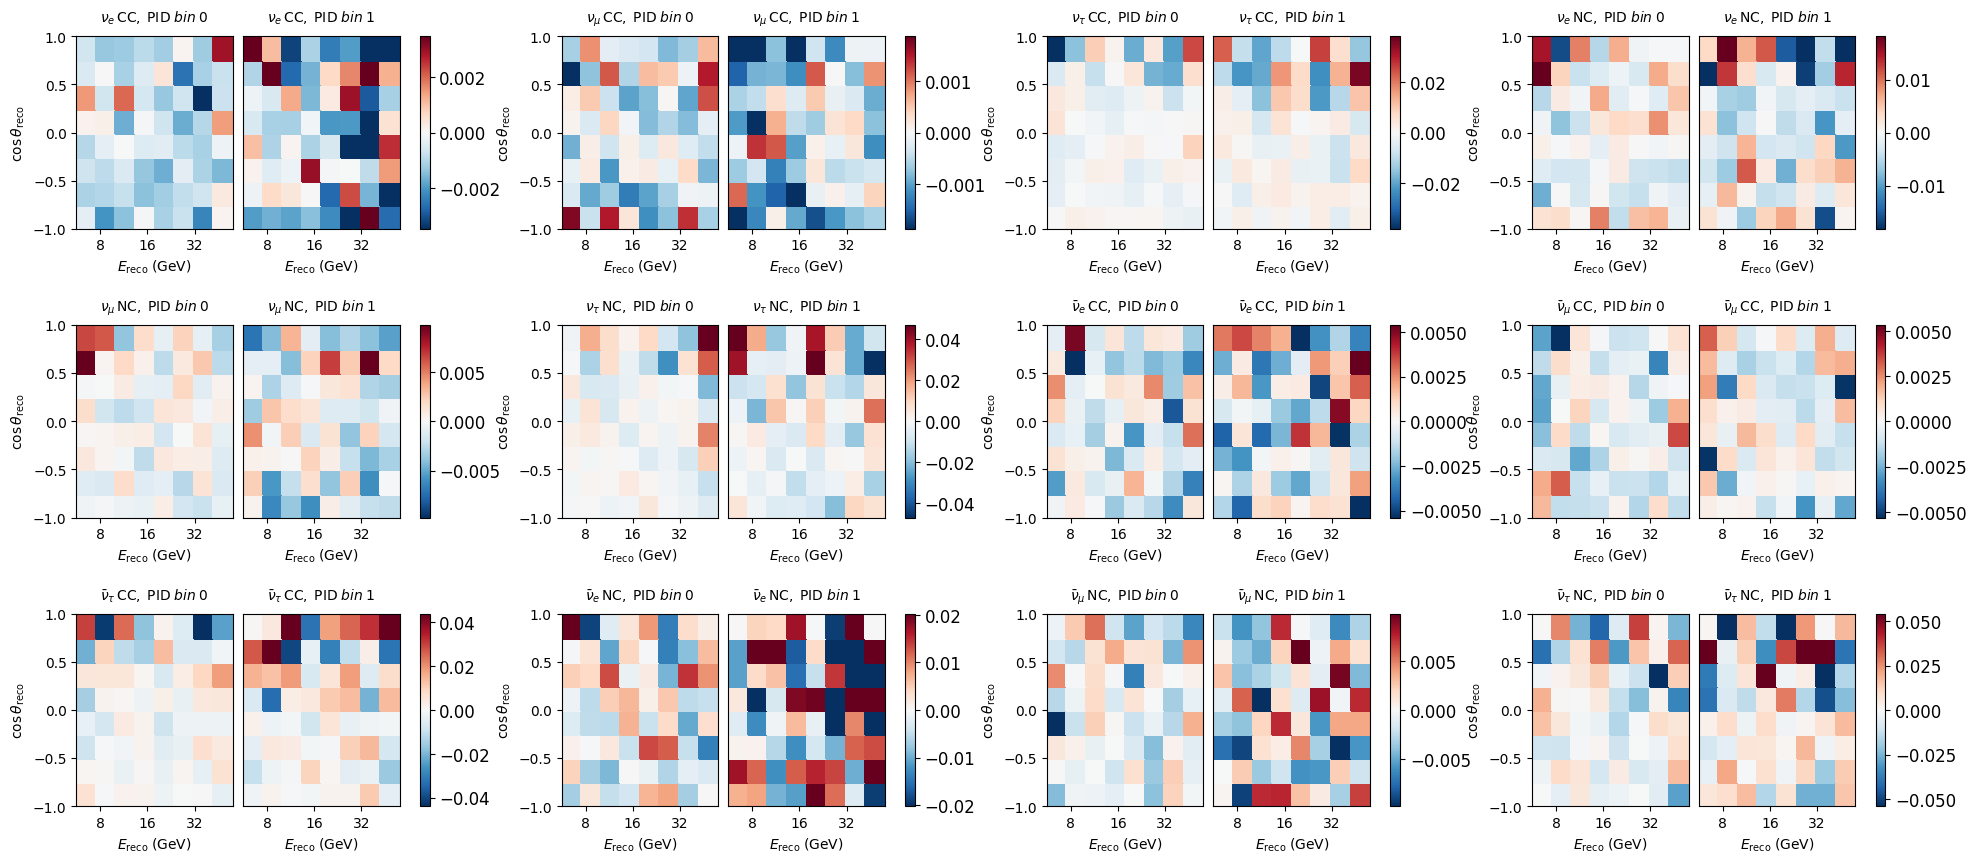

In [12]:
fig, axes = plt.subplots(3,4, figsize=(24,10))
plt.subplots_adjust(hspace=0.5)
axes = axes.flatten()

diff = (events - mixed) / (events + 1e-7)

for m, ax in zip(diff, axes):
    m.plot(ax=ax, symm=True)

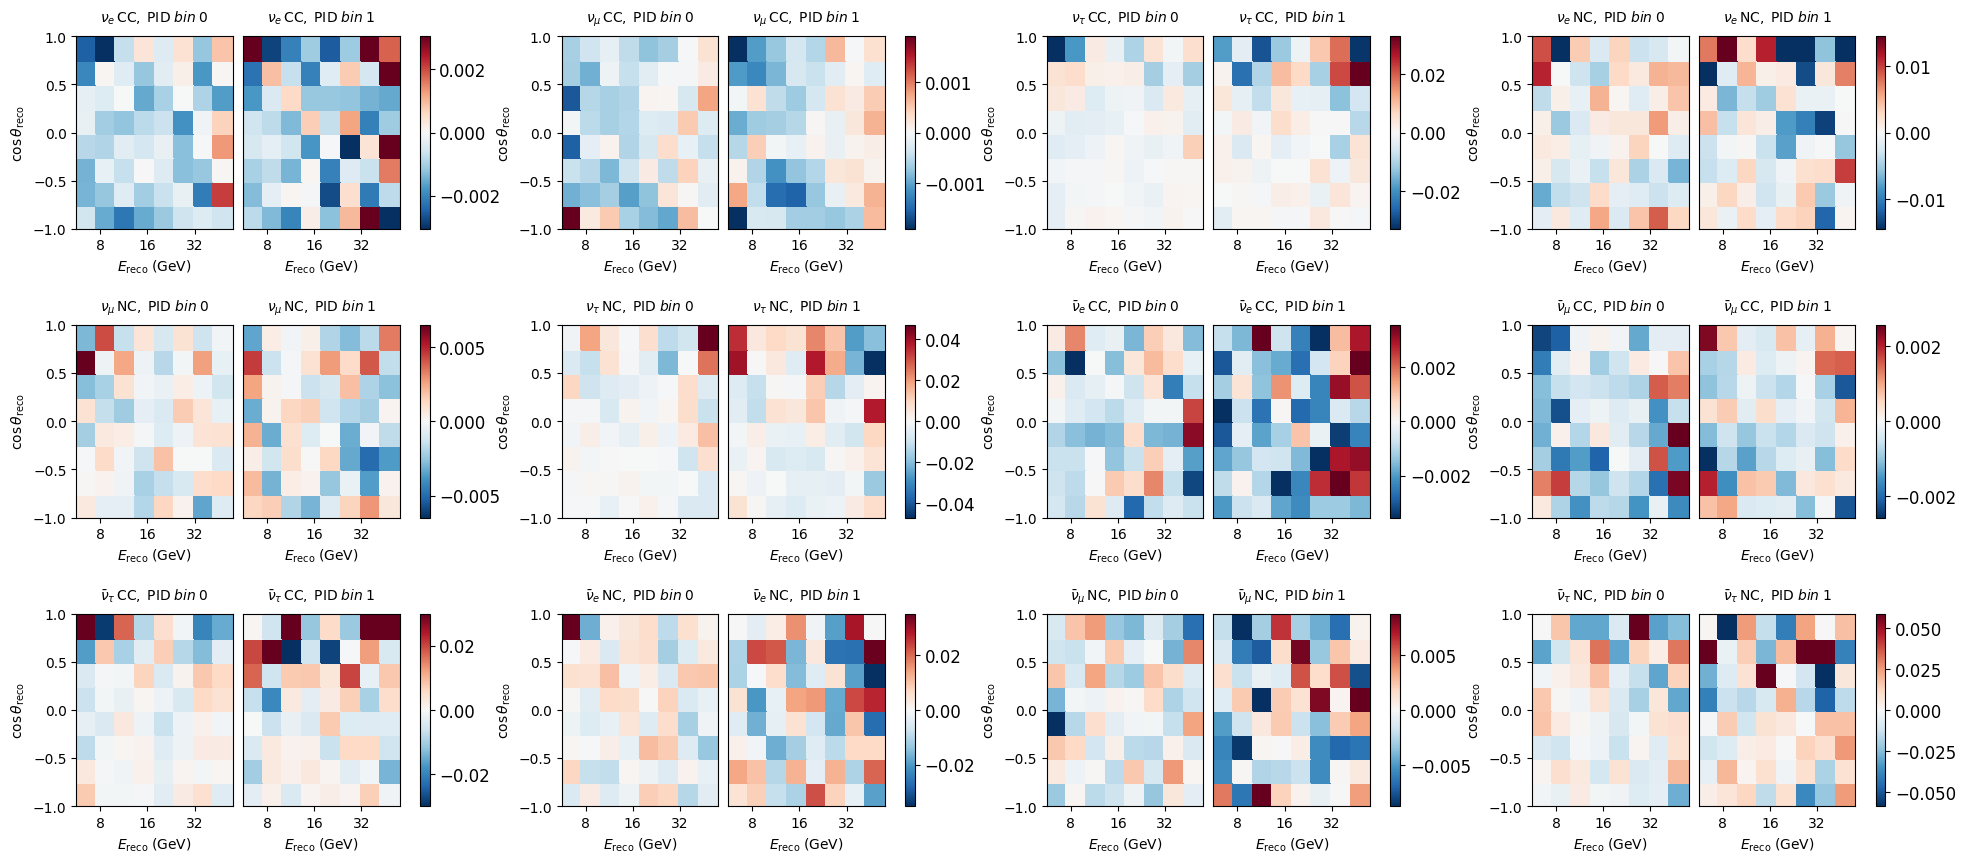

In [13]:
fig, axes = plt.subplots(3,4, figsize=(24,10))
plt.subplots_adjust(hspace=0.5)
axes = axes.flatten()

diff = (events - grid) / (events + 1e-7)

for m, ax in zip(diff, axes):
    m.plot(ax=ax, symm=True)